# SewerTris — Test Suite: description & execution

This notebook **documents and runs** the automated tests for the 12-step
SewerTris pipeline. It is meant to be read top-to-bottom: each section explains
what is being verified and then executes the relevant tests so you can see the
results inline.

**What gets tested**

| # | Pipeline step | Project method |
|---|---------------|----------------|
| 1 | Urban domain definition | `define_domain` |
| 2 | Tetromino block definition | `get_tetromino_set` / `define_tetrominoes` |
| 3 | Stochastic tetris completion | `complete_tetris_layout` |
| 4 | Road network extraction | `generate_roads` / `extract_road_boundaries` |
| 5 | Land-use assignment | `assign_land_use` |
| 6 | Synthetic DEM generation | `generate_topography` |
| 7 | Sewer network generation (+ DEM embedding) | `generate_sewer_network_V2` / `embed_sewer_network_in_dem` |
| 8 | Sewer flow predesign (DWF/GWI/RDII) | `predesign_flows` |
| 9 | Pipe sizing & hydraulic properties | `design_pipes` |
| 10 | Dynamic flow input definition (SWMM `.inp`) | `export_swmm` |
| 11 | EPA-SWMM simulation | `SewerTrisScenario.run_swmm` |
| 12 | Flow output decomposition | `SewerTrisScenario.get_flow_components` |


## How the tests are organised

```
tests/
├── conftest.py              # shared, session-scoped fixture CHAIN (build the
│                            #   pipeline once on a small known-good domain) +
│                            #   real call parameters as module constants
├── test_pipeline_steps.py   # one real-execution test per step (1..12) + a
│                            #   pure unit test for the BC peaking factor
├── test_end_to_end.py       # slow integration smoke test (all 12 steps)
└── test_package_api.py      # pre-existing API-plumbing tests (heavily mocked)
```

**Design choices (good practice):**

* The pipeline is **sequential**, so the fixtures in `conftest.py` build it
  **once** through a chain (`domain_project → layout_project → … →
  swmm_project → swmm_ran → flow_components`). Each per-step test then asserts
  on that step's real output. A failure in one step only fails that step's
  fixture and its dependents — earlier steps still report independently.
* Tests assert **physical / structural invariants** (e.g. *the DEM drains to the
  outlet*, *pipe inverts run downhill*, *flow components never exceed the
  modelled total*), not brittle exact values.
* Steps **11–12** run a **real EPA-SWMM simulation** and are marked
  `@pytest.mark.slow`, so the fast geometry/hydrology subset can be run on its
  own with `-m "not slow"`.
* The pre-existing `test_package_api.py` mocks every heavy step (it only checks
  the API wiring); the tests here add the missing *behavioural* coverage.


## Setup

We run everything with the **current kernel's interpreter** (`sys.executable`),
which should be the `sewertris` conda environment (it provides `pyswmm`,
`geopandas`, `rasterio`, `pytest`, …). All commands run from the repository
root so pytest picks up `pyproject.toml`.


In [1]:
import os, sys
from pathlib import Path

%matplotlib inline

# Locate the repository root (this notebook lives in <repo>/tests).
here = Path.cwd()
REPO_ROOT = here if (here / "src" / "sewertris").exists() else here.parent
os.chdir(REPO_ROOT)
print("Repo root :", REPO_ROOT)
print("Python    :", sys.executable)

import importlib.metadata as md
for pkg in ["pytest", "pyswmm", "geopandas", "rasterio", "numpy"]:
    try:
        print(f"  {pkg:10s} {md.version(pkg)}")
    except md.PackageNotFoundError:
        print(f"  {pkg:10s} MISSING")


Repo root : /Users/kevinblanco/Documents/Sewertris
Python    : /opt/anaconda3/envs/sewertris/bin/python
  pytest     9.1.1
  pyswmm     2.0.1
  geopandas  1.1.3
  rasterio   1.4.3
  numpy      2.2.6


## 1. Discover the tests

`--collect-only` lists every test the suite will run (without executing them).


In [2]:
!{sys.executable} -m pytest --collect-only -q

tests/test_end_to_end.py::test_full_pipeline_produces_all_artifacts_and_flow_components
tests/test_package_api.py::test_top_level_api_exports_expected_functions
tests/test_package_api.py::test_named_tetromino_set_helper_returns_four_piece_sibling
tests/test_package_api.py::test_plot_two_models_compares_project_domain_masks
tests/test_package_api.py::test_plot_ensemble_results_summarizes_flow_components
tests/test_package_api.py::test_submodule_api_remains_available
tests/test_package_api.py::test_complete_tetris_layout_seed_is_reproducible
tests/test_package_api.py::test_project_saves_loads_json_metadata
tests/test_package_api.py::test_project_load_resolves_legacy_relative_output_dir_to_project_file_parent
tests/test_package_api.py::test_project_creates_scenario_folder_without_base_inp
tests/test_package_api.py::test_project_clone_sibling_copies_reusable_domain_state
tests/test_package_api.py::test_sibling_replay_applies_road_width_change
tests/test_package_api.py::test_sibling_replay_

## 2. Fast subset — steps 1–10 + unit test  (`-m "not slow"`)

These tests run the **real** geometry, topography, network, hydrology and pipe
sizing computations on a small synthetic city, then assert each step's output.
No EPA-SWMM run, so they are quick.

What each step test checks:

| Test | Asserts |
|------|---------|
| `test_step01_*` | domain mask shape + persisted grid metadata |
| `test_step02_*` | the `full` tetromino set has the 7 canonical pieces |
| `test_step03_*` | the layout tiles the whole domain; seed is recorded |
| `test_step04_*` | roads have geometry and preserve the CRS |
| `test_step05_*` | every block receives a known land-use class |
| `test_step06_*` | DEM is elevation-bounded **and drains toward the outlet** |
| `test_step07_*` | a connected, tiered (main/secondary/tertiary) pipe tree with one outlet |
| `test_step08_*` | non-negative DWF/GWI/RDII accumulation with downstream growth |
| `test_step09_*` | commercial diameters, Manning *n* by material, **downhill inverts** |
| `test_step10_*` | SWMM `.inp` has all required sections + one conduit per pipe |
| `test_british_columbia_peaking_factor_*` | peaking factor bounded `[2.5, 4.0]` and monotone |


In [3]:
!{sys.executable} -m pytest -m "not slow" -v

============================= test session starts ==============================
platform darwin -- Python 3.10.13, pytest-9.1.1, pluggy-1.6.0 -- /opt/anaconda3/envs/sewertris/bin/python
cachedir: .pytest_cache
rootdir: /Users/kevinblanco/Documents/Sewertris
configfile: pyproject.toml
testpaths: tests
plugins: anyio-4.14.1
collected 33 items / 3 deselected / 30 selected                                

tests/test_package_api.py::test_top_level_api_exports_expected_functions PASSED [  3%]
tests/test_package_api.py::test_named_tetromino_set_helper_returns_four_piece_sibling PASSED [  6%]
tests/test_package_api.py::test_plot_two_models_compares_project_domain_masks PASSED [ 10%]
tests/test_package_api.py::test_plot_ensemble_results_summarizes_flow_components PASSED [ 13%]
tests/test_package_api.py::test_submodule_api_remains_available PASSED   [ 16%]
tests/test_package_api.py::test_complete_tetris_layout_seed_is_reproducible PASSED [ 20%]
tests/test_package_api.py::test_project_saves_load

## 3. Slow tests — real EPA-SWMM  (`-m slow`)

These run an actual PySWMM simulation on the generated model and then decompose
the outlet hydrograph.

| Test | Asserts |
|------|---------|
| `test_step11_*` | SWMM runs, returns non-empty depth/flow series, no fatal `ERROR`, mass-balance continuity within tolerance |
| `test_step12_*` | outlet flow splits into `DWF` / `GWI` / `RDII_runoff`; components are non-negative and never exceed the modelled total |
| `test_full_pipeline_*` (end-to-end) | every stage left its artifact on disk and the final decomposition is physically sane |


In [4]:
!{sys.executable} -m pytest -m slow -v

============================= test session starts ==============================
platform darwin -- Python 3.10.13, pytest-9.1.1, pluggy-1.6.0 -- /opt/anaconda3/envs/sewertris/bin/python
cachedir: .pytest_cache
rootdir: /Users/kevinblanco/Documents/Sewertris
configfile: pyproject.toml
testpaths: tests
plugins: anyio-4.14.1
collected 33 items / 30 deselected / 3 selected                                

tests/test_end_to_end.py::test_full_pipeline_produces_all_artifacts_and_flow_components PASSED [ 33%]
tests/test_pipeline_steps.py::test_step11_swmm_runs_and_reports_flow PASSED [ 66%]
tests/test_pipeline_steps.py::test_step12_flow_components_decompose_total PASSED [100%]

=============================== warnings summary ===============================
tests/test_end_to_end.py::test_full_pipeline_produces_all_artifacts_and_flow_components
  /opt/anaconda3/envs/sewertris/lib/python3.10/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and wi

> The full suite (fast **and** slow) is simply `pytest -q` from the repo
> root. Run `pytest -m "not slow"` for a quick check that skips the SWMM run.

---

## Appendix — what the tests actually build

The cells below reproduce the fixture chain from `conftest.py` (reusing the same
constants) so you can *see* the synthetic system and the decomposed hydrograph
that the assertions above are checking. This is illustrative only — the tests
themselves run this in isolated temp directories.


✅ Exported 51 figures to /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/city_layout.gpkg
[OK] Boundary lines written to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/road_boundary_lines.gpkg
[OK] Outer shell polygon(s) written to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/road_outer_shell.gpkg
✅ Exported to /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/city_blocks.gpkg
Original boundary CRS: EPSG:3857
Original roads CRS: EPSG:3857

Boundary extent:
X range: -5.00 to 1705.00
Y range: -5.00 to 1005.00
Boundary CRS: EPSG:3857
Boundary bounds: [  -5.   -5. 1705. 1005.]
Grid shape: (122, 192)
Grid extent:
  X: -110.00 to 1810.00
  Y: -110.00 to 1110.00
Creating mask...
Processing row 0 of 122
Processing row 100 of 122
Outlet cell: (111, 91)
Computing geodesic distances...
Processing roads...


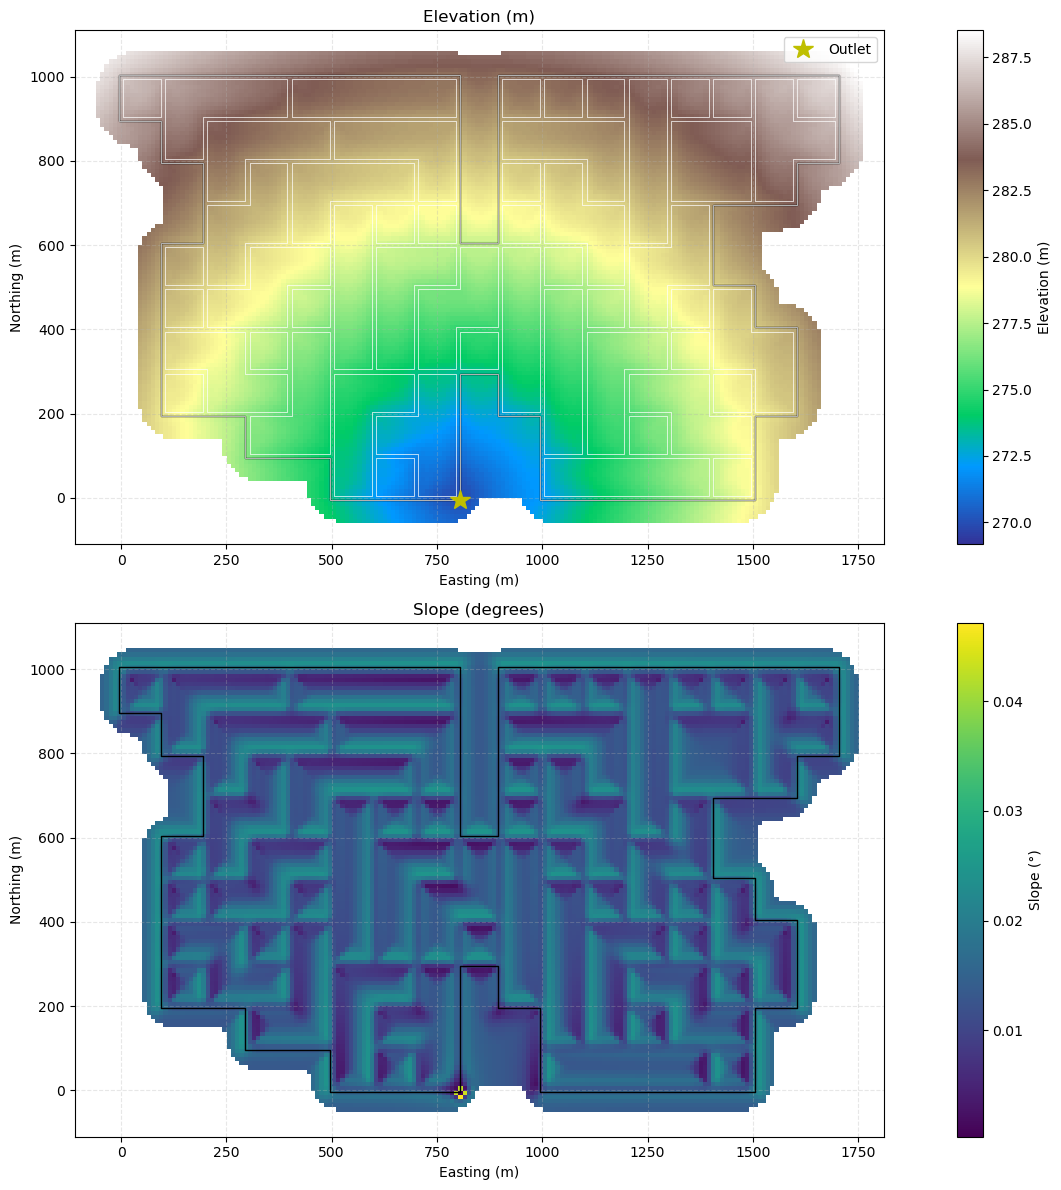


Terrain Statistics:
Elevation range: 269.18m - 288.52m
Mean elevation: 279.40m
Mean slope: 0.01°
Max slope: 0.05°

Drainage Statistics:
Points with proper drainage: 17293.0 out of 19926 (86.8%)
✅ Extracted 135 manholes from road centerlines.
✅ Manholes exported to /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/manholes.gpkg

Path Statistics:
Head: MH127  →  Target: MH011
Segments: 16
Total length: 1900.0 m
Total drop: 18.47 m
Avg slope: 0.895%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 53 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
📊 V2 initial missing outlet pipes: 65
V2 iteration 1: start=MH009, status=committed, chain_len=10, cost=2485.53, remaining=55
V2 iteration 2: start=MH022, status=committed, chain_len=1, cost=108.46, remaining=54
V2 iteration 3: start=MH034, status=committed, chain_len=1, cost=100.00, remaining=53
V2 iteration 4: start=MH039, status=committed, chain_len=3, cost=422.37, remaining

/opt/anaconda3/envs/sewertris/lib/python3.10/site-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 4 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


✅ Pipe slopes assigned and saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/sewer_pipes.gpkg
✅ Materials and diameters assigned and saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/sewer_pipes.gpkg
✅ Invert elevations assigned and saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/sewer_pipes.gpkg
✅ Pipes saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/sewer_pipes.gpkg
✅ Manholes saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/manholes.gpkg
✅ SWMM .inp file written to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/sewer_model.inp
Built pipeline in: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo


In [5]:
import tempfile
import numpy as np

sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(REPO_ROOT / "tests"))
import sewertris as sp
import conftest as C   # reuse the exact test parameters (domain, options, rainfall, ...)

work = Path(tempfile.mkdtemp(prefix="sewertris_demo_"))
project = sp.SewerTrisProject(work / "demo", cell_size_m=C.CELL_SIZE_M, autosave=False)

# Steps 1-3: domain + tetromino layout
mask, grid_meta = C.make_domain_mask()
project.define_domain(domain_mask=mask, cell_size_m=C.CELL_SIZE_M, grid_meta=grid_meta)
tetrominoes, colors = sp.get_tetromino_set("full")
project.define_tetrominoes(tetrominoes, colors)
project.complete_tetris_layout(seed=1000, georeferenced=True)

# Steps 4-6: roads, land use, DEM
project.generate_roads(road_width=10, simplify_tol=0.5)
project.extract_road_boundaries(keep_holes=False)
project.assign_land_use(land_use_distribution=C.LAND_USE_DISTRIBUTION, seed=42)
config = sp.TopographyConfig(min_elevation=270, max_elevation=290, cell_size=10,
                             outlet_direction="S", smoothing_factor=1)
project.generate_topography(boundary_path=project.road_outer_shell_path,
                            roads_path=project.road_polygons_path, config=config)

# Step 7: sewer network + DEM embedding
project.generate_sewer_network_V2(
    road_width=10, block_size=C.CELL_SIZE_M * 2,
    main_slope_tolerance=-0.01, secondary_slope_tolerance=0.0, prefer_slope=0.5,
    tertiary_block_size=C.CELL_SIZE_M * 10, neighbor_radius_factor=1.5,
    tertiary_min_pipe_length=1e-3, point_on_line_tol=0.01,
    tertiary_adverse_slope_weight=200.0, tertiary_mild_adverse_slope=-0.005,
    tertiary_moderate_adverse_slope=-0.01, tertiary_severe_adverse_multiplier=8.0,
)
project.embed_sewer_network_in_dem(
    upstream_field="upstream_m", downstream_field="downstream_m",
    manhole_id_field="id", manhole_elev_field="elevation", type_field="type",
    tier_order=("main", "secondary", "tertiary"), Smin=0.001, along_pipe_weight=2,
    idw_power=2.0, idw_k=12, idw_tile=1024, centerline_writeback=True, verify_on_raster=True,
)

# Steps 8-10: predesign, pipe sizing, SWMM export
project.predesign_flows(land_use_info=C.LAND_USE_INFO,
                        gwi_factor_ls_per_m=0.0002, rdii_factor_ls_per_m2=0.00002)
project.design_pipes(minimum_slope=C.MINIMUM_SLOPE, material_fractions=C.MATERIAL_FRACTIONS,
                     n_by_material=C.N_BY_MATERIAL, standard_diameters_mm=C.STANDARD_DIAMETERS_MM,
                     minimum_diameter_mm=C.MINIMUM_DIAMETER_MM)
project.export_swmm(options_dict=C.SWMM_OPTIONS)
print("Built pipeline in:", project.output_dir)


### The synthetic sewer network (what step 7 verifies)

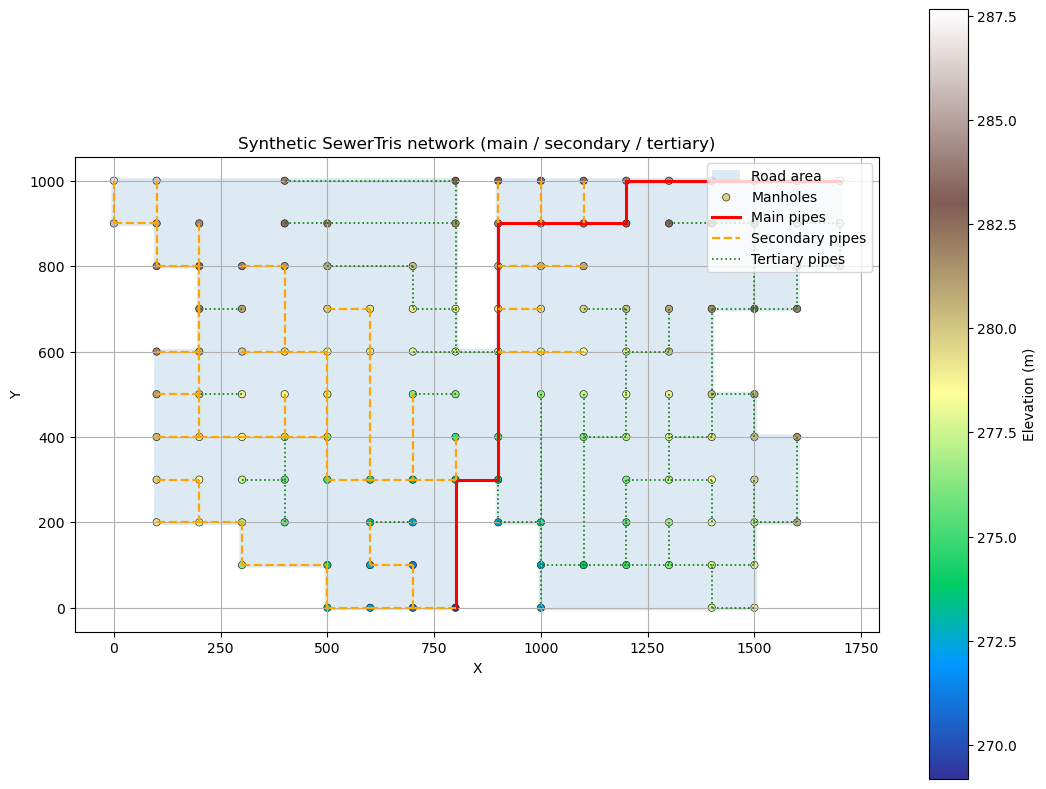

In [6]:
sp.plot_sewer_network_all(
    manholes=project.state["manholes"],
    main_pipes=project.state["main_path"],
    secondary_pipes=project.state["secondary_pipes"],
    tertiary_pipes=project.state["tertiary_pipes"],
    unresolved=project.state["tertiary_unconnected"],
    road_buffer=project.state["road_buffer"],
    title="Synthetic SewerTris network (main / secondary / tertiary)",
)


### Steps 11–12: run SWMM and decompose the outlet flow

This is exactly what `test_step11_*`, `test_step12_*` and the end-to-end test
exercise: drive the model with DWF patterns + GWI + an RDII storm, run EPA-SWMM,
and split the outlet hydrograph into its components.


In [7]:
scenario = project.create_run("demo_run")
scenario.assign_dwf_patterns(
    hourly_id="1", hourly_values=C.DWF_HOURLY,
    daily_id="2", daily_values=C.DWF_DAILY,
    monthly_id="3", monthly_values=C.DWF_MONTHLY,
    weekend_id="4", weekend_values=C.DWF_WEEKEND,
)
scenario.assign_gwi_from_pipe_length(coefficient=C.GWI_COEFFICIENT)
scenario.add_subcatchment_rdii(
    raingage_id="1", raingage_coords=(500, 500), timeseries=C.RDII_RAINFALL,
    interval="0:30", n_imperv=0.011, n_perv=0.15, s_imperv=0.0, s_perv=0.0,
    pct_zero=0, route_to="OUTLET", pct_routed="",
    infiltration_params=(30, 0.5, 7, "", ""), imperv_pct=2, width=100, slope=0.005, curblen=0,
)
scenario.add_pollutant_tags()
df = scenario.get_flow_components(link_id="P_OUTLET")
df[["Datetime", "Flow_model_units", "DWF", "GWI", "RDII_runoff"]].head()


✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/scenarios/demo_run/sewer_model.inp
✅ INFLOWS section created using coefficient 0.0001. File saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/scenarios/demo_run/sewer_model.inp
✅ SWMM .inp file updated with subcatchments and saved to: /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/scenarios/demo_run/sewer_model.inp
✅ Tagged inp written (uses CONCEN) -> /var/folders/2w/7qxwf1vx23j4x3ffy2bx46180000gn/T/sewertris_demo_th9vb73d/demo/scenarios/demo_run/sewer_model.inp


,Datetime,Flow_model_units,DWF,GWI,RDII_runoff
0,2025-01-01 00:01:00,0.000000,0.0,0.0,0.000000
1,2025-01-01 00:02:00,0.000000,0.0,0.0,0.000000
2,2025-01-01 00:03:00,0.000000,0.0,0.0,0.000000
3,2025-01-01 00:04:00,0.007485,0.0,0.0,0.007485
4,2025-01-01 00:05:00,0.008164,0.0,0.0,0.008164


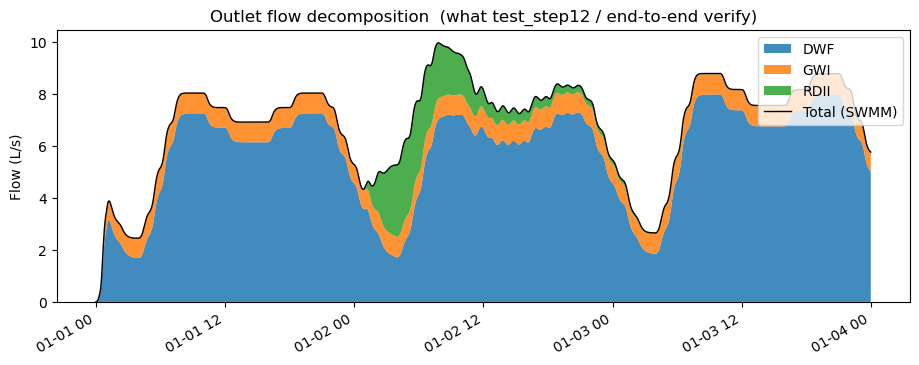

DWF volume share : 83.3%
GWI volume share : 11.3%
RDII volume share: 5.4%


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(df["Datetime"], df["DWF"], df["GWI"], df["RDII_runoff"],
             labels=["DWF", "GWI", "RDII"], alpha=0.85)
ax.plot(df["Datetime"], df["Flow_model_units"], color="black", lw=1.0, label="Total (SWMM)")
ax.set_ylabel("Flow (L/s)")
ax.set_title("Outlet flow decomposition  (what test_step12 / end-to-end verify)")
ax.legend(loc="upper right")
fig.autofmt_xdate()
plt.show()

print("DWF volume share : %.1f%%" % (100 * df["DWF"].sum() / df["Flow_model_units"].sum()))
print("GWI volume share : %.1f%%" % (100 * df["GWI"].sum() / df["Flow_model_units"].sum()))
print("RDII volume share: %.1f%%" % (100 * df["RDII_runoff"].sum() / df["Flow_model_units"].sum()))


---

### Running the tests from a terminal

```bash
# fast geometry / hydrology / design subset
python -m pytest -m "not slow" -q

# everything, including the real EPA-SWMM simulation
python -m pytest -q
```

Use the `sewertris` environment's interpreter, e.g.
`/opt/anaconda3/envs/sewertris/bin/python -m pytest`.
